=== MEMULAI PROSES KNOWLEDGE DISCOVERY (V2: FILTERED N-GRAM) ===
✅ Selesai! Cek gambar 'top_10_frasa_sentimen_V2.png'


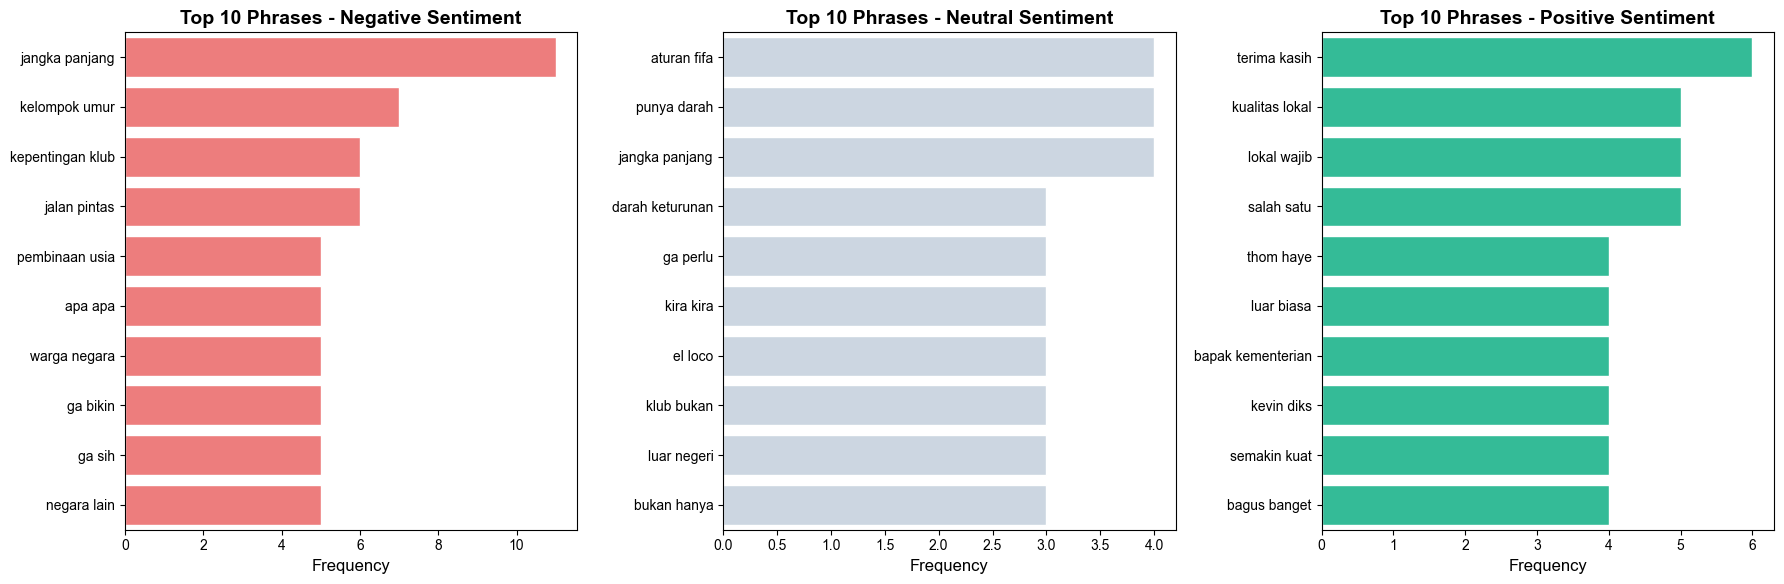

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

print("=== MEMULAI PROSES KNOWLEDGE DISCOVERY (V2: FILTERED N-GRAM) ===")

# 1. Load Data
df = pd.read_csv("../data_labelling/train_labeled.csv")
df['label'] = df['label'].astype(int)

# ==========================================
# 2. BIKIN KAMUS "BLACKLIST" KATA (Domain Stopwords)
# ==========================================
# Kita buang kata-kata topik dan kata sambung yang bikin semak!
custom_stopwords = [
    'timnas', 'indonesia', 'pemain', 'naturalisasi', 'bola', 'sepak', 
    'di', 'ke', 'dari', 'yang', 'dan', 'ini', 'itu', 'untuk', 'dengan', 
    'ada', 'adalah', 'nya', 'ya', 'yg', 'utk', 'aja', 'buat', 'kan', 
    'main', 'liga', 'orang', 'kalau', 'kalo', 'bisa', 'lebih', 'sudah',
    'gak', 'tidak', 'udah', 'sama', 'juga', 'dalam', 'kita', 'mereka',
    'gara', 'karena', 'krn', 'dari', 'pada', 'atau', 'jadi',
    # --- TAMBAHAN BARU: NAMA TOKOH & EVENT BIAR ARGUMENNYA MUNCUL ---
    'shin', 'tae', 'yong', 'erick', 'thohir', 'pak', 'coach',
    'piala', 'dunia', 'asia', 'sandy', 'walsh', 'jordi', 'amat',
    'beritabola', 'timnasindonesia', 'indra', 'sjafri'
]

# 3. Fungsi narik N-Gram dengan Stopwords
def get_top_ngrams(corpus, n=10, ngram_range=(2, 2)):
    # Masukin custom_stopwords ke dalam Vectorizer
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=custom_stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# 4. Pisahin data berdasarkan kelas
df_neg = df[df['label'] == 0]['cleaned_text'].astype(str)
df_neu = df[df['label'] == 1]['cleaned_text'].astype(str)
df_pos = df[df['label'] == 2]['cleaned_text'].astype(str)

# Ekstrak Top 10 Frasa
top_neg = get_top_ngrams(df_neg, n=10)
top_neu = get_top_ngrams(df_neu, n=10)
top_pos = get_top_ngrams(df_pos, n=10)

# Konversi ke DataFrame
df_top_neg = pd.DataFrame(top_neg, columns=['Frasa', 'Frekuensi'])
df_top_neu = pd.DataFrame(top_neu, columns=['Frasa', 'Frekuensi'])
df_top_pos = pd.DataFrame(top_pos, columns=['Frasa', 'Frekuensi'])

# 5. PLOTTING
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x='Frekuensi', y='Frasa', data=df_top_neg, ax=axes[0], color='#ff6b6b')
axes[0].set_title('Top 10 Phrases - Negative Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].set_ylabel('')

sns.barplot(x='Frekuensi', y='Frasa', data=df_top_neu, ax=axes[1], color='#c8d6e5')
axes[1].set_title('Top 10 Phrases - Neutral Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_ylabel('')

sns.barplot(x='Frekuensi', y='Frasa', data=df_top_pos, ax=axes[2], color='#1dd1a1')
axes[2].set_title('Top 10 Phrases - Positive Sentiment', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequency', fontsize=12)
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('top_10_frasa_sentimen_V2.png', dpi=300, bbox_inches='tight')
print("✅ Selesai! Cek gambar 'top_10_frasa_sentimen_V2.png'")

plt.show()